In [1]:
import numpy as np
import gymnasium as gym
import tqdm

from tqdm.notebook import tqdm

In [2]:
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")

In [3]:
print(f'observation space: {env.observation_space}')
print(f'samle observation: {env.observation_space.sample()}')

observation space: Discrete(16)
samle observation: 3


In [4]:
print(f'action space: {env.action_space.n}')
print(f'action spce sample: {env.action_space.sample()}')

action space: 4
action spce sample: 0


In [5]:
state_space = 16
action_space = 4

In [6]:
def initialize_q_table(state_space, action_space):
    Qtable = np.zeros((state_space, action_space))
    return Qtable

In [7]:
Qtable_frozenlake = initialize_q_table(state_space, action_space)

In [8]:
def greedy_policy(Qtable, state):
    action = np.argmax(Qtable[state][:])
    return action

In [9]:
def epsilon_greedy_policy(Qtable, state, epsilon):
    random_num = np.random.random()
    if random_num > epsilon:
        action = np.argmax(Qtable[state][:])
    else:
        action = env.action_space.sample()
    return action

In [10]:
n_training_episodes = 500_000
learning_rate = 0.001

n_eval_episodes = 1000

env_id = "FrozenLake-v1"
max_steps = 200
gamma = 0.99
eval_seed = []

max_epsilon = 1.0
min_epsilon = 0.01
decay_rate = 0.000005

In [11]:
def train(n_training_episodes, min_epsilon, max_epsilon, decay_rate, env, max_steps, Qtable):
    for episode in tqdm(range(n_training_episodes)):
        epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)

        state, info = env.reset()
        step = 0
        terminated = False
        truncated = False

        for step in range(max_steps):
            action = epsilon_greedy_policy(Qtable, state, epsilon)

            new_state, reward, terminated, truncated, info = env.step(action)

            Qtable[state][action] += learning_rate * (reward + gamma * np.max(Qtable[new_state]) - Qtable[state][action])

            if terminated or truncated:
                break

            state = new_state
    return Qtable

In [12]:
Qtable_frozenlake = train(n_training_episodes, min_epsilon, max_epsilon, decay_rate, env, max_steps, Qtable_frozenlake)

  0%|          | 0/500000 [00:00<?, ?it/s]

In [13]:
Qtable_frozenlake

array([[0.94148015, 0.95099005, 0.95099005, 0.94148015],
       [0.94148015, 0.        , 0.96059601, 0.95099005],
       [0.95099005, 0.970299  , 0.95099005, 0.96059601],
       [0.96059601, 0.        , 0.94761163, 0.94779695],
       [0.94962907, 0.96059601, 0.        , 0.94111064],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.9801    , 0.        , 0.96059601],
       [0.        , 0.        , 0.        , 0.        ],
       [0.95827746, 0.        , 0.970299  , 0.9472199 ],
       [0.95921721, 0.97855023, 0.9801    , 0.        ],
       [0.970299  , 0.99      , 0.        , 0.970299  ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.95073654, 0.99      , 0.94207463],
       [0.9801    , 0.99      , 1.        , 0.9801    ],
       [0.        , 0.        , 0.        , 0.        ]])

In [14]:
def evaluate_agent(env, max_steps, n_eval_episodes, Q, seed):
    episode_rewards = []
    for episode in tqdm(range(n_eval_episodes)):
        if seed:
            state, info = env.reset(seed=seed[episode])
        else:
            state, info = env.reset()
        step = 0
        truncated = False
        terminated = False
        total_rewards_ep = 0

        for step in range(max_steps):
            action = greedy_policy(Q, state)
            new_state, reward, terminated, truncated, info = env.step(action)
            total_rewards_ep += reward

            if terminated or truncated:
                break
            state = new_state
        episode_rewards.append(total_rewards_ep)
    mean_reward, std_reward = np.mean(episode_rewards), np.std(episode_rewards)

    return mean_reward, std_reward

In [15]:
mean_reward, std_reward = evaluate_agent(env, max_steps, n_eval_episodes, Qtable_frozenlake, eval_seed)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [16]:
print(f'mean reward: {mean_reward}, std reward: {std_reward}')

mean reward: 1.0, std reward: 0.0


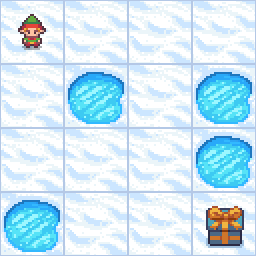

In [17]:
import gymnasium as gym
import numpy as np
import imageio.v2 as imageio
from IPython.display import Image, display

env_vis = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
state, _ = env_vis.reset(seed=42)

frames = [env_vis.render()]
for _ in range(max_steps):
    action = int(np.argmax(Qtable_frozenlake[state]))
    state, reward, terminated, truncated, _ = env_vis.step(action)
    frames.append(env_vis.render())
    if terminated or truncated:
        break

env_vis.close()

gif_path = "frozenlake_run.gif"
imageio.mimsave(gif_path, frames, duration=0.5, loop=0)
display(Image(filename=gif_path))
